# llama3.1:8b — results

How well **llama3.1:8b** labels Data Management Plans, using **pdfplumber** to read the
PDFs. Scored against a human annotation of the same 10 documents.


In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from dmpbridge.evaluation.evaluate import (
    load_method as load_method_old, micro_prf1, compute_f1_rows, LABELS,
)

MODEL, TAG = 'llama3.1:8b', 'llama3.1-8b_pdfplumber_whole_doc'

BLUE, BLUE_DARK = '#2a78d6', '#1c5cab'
INK, MUTED, SURFACE = '#0b0b0b', '#52514e', '#fcfcfb'
RAMP = ['#cde2fb', '#b7d3f6', '#9ec5f4', '#86b6ef', '#6da7ec',
        '#5598e7', '#3987e5', '#2a78d6', '#256abf', '#1c5cab', '#184f95']
BLUES = LinearSegmentedColormap.from_list('dmp_blue', ['#ffffff'] + RAMP)

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.edgecolor': '#d8d8d4', 'axes.titlecolor': INK,
    'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
})

df, conf, errors = load_method_old(TAG, exclude=[])
print(f'{MODEL} — {len(df)} documents')


llama3.1:8b — 10 documents


## Step 1 — The measures, and the results

Every piece of text in the human annotation is compared with what the model produced.
Four outcomes are possible:

| | |
|---|---|
| **correct** | the model found the text and gave it the right label |
| **wrong label** | it found the text but called it something else |
| **missed** | the model produced nothing matching it |
| **invented** | the model produced something the annotation does not contain |

From those counts:

**Precision** — of everything the model produced, how much was right?

> precision = correct ÷ everything produced

**Recall** — of everything in the human annotation, how much did the model find?

> recall = correct ÷ everything in the annotation

**F1** — the two combined into one number. It stays low unless *both* are high, so a
model cannot score well by producing very little, or by producing everything it can
think of.

> F1 = 2 × precision × recall ÷ (precision + recall)

**Confusion matrix** — a grid of every decision made: what the text really was, against
what the model called it. Shown in step 3.


llama3.1:8b  ·  all 10 documents

  correct             96
  wrong or invented   82
  missed              36

  Precision    53.9%
  Recall       72.7%
  F1           61.9%


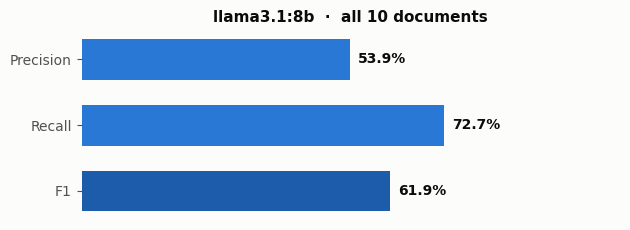

In [2]:
m = micro_prf1(conf)

print(f'{MODEL}  ·  all 10 documents')
print()
print(f"  correct           {m['tp']:>4}")
print(f"  wrong or invented {m['fp']:>4}")
print(f"  missed            {m['fn']:>4}")
print()
print(f"  Precision   {m['precision'] * 100:5.1f}%")
print(f"  Recall      {m['recall'] * 100:5.1f}%")
print(f"  F1          {m['f1'] * 100:5.1f}%")

fig, ax = plt.subplots(figsize=(6.4, 2.4))
vals = [m['precision'] * 100, m['recall'] * 100, m['f1'] * 100]
bars = ax.barh(['Precision', 'Recall', 'F1'], vals,
               color=[BLUE, BLUE, BLUE_DARK], height=0.62)
for b, v in zip(bars, vals):
    ax.text(v + 1.5, b.get_y() + b.get_height() / 2, f'{v:.1f}%',
            va='center', fontweight='bold', color=INK)
ax.set_xlim(0, 108)
ax.set_xticks([])
ax.invert_yaxis()
ax.set_title(f'{MODEL}  ·  all 10 documents')
for side in ('top', 'right', 'left', 'bottom'):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()


## Step 2 — Macro F1

The score above pools every item together, so the labels that appear most often carry
the most weight.

**Macro F1** does the opposite: it scores each of the five labels separately, then takes
a plain average. Every label counts equally, however rare it is. A model that handles
the common labels well but fails on a rare one is not rewarded for the imbalance.


label                     Precision   Recall       F1   items
-------------------------------------------------------------
title                         90.0%    90.0%    90.0%      10
section.title                 59.3%    81.4%    68.6%      43
section.description           75.0%    75.0%    75.0%       8
question.text                  3.1%     6.2%     4.2%      16
answer.text                   65.2%    81.8%    72.6%      55
-------------------------------------------------------------
MACRO (average)               58.5%    66.9%    62.1%

  Macro F1  62.1%   every label counts equally
  Micro F1  61.9%   every item counts equally (step 1)


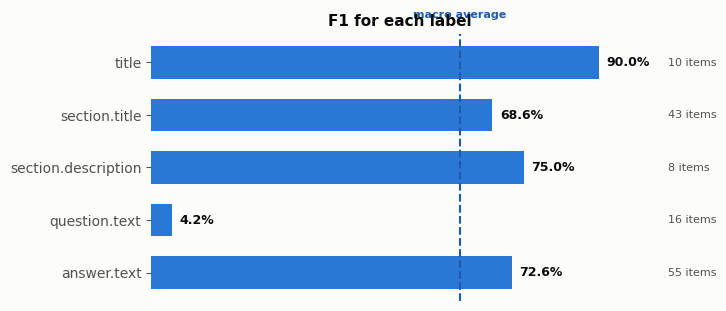

In [3]:
per_label = compute_f1_rows(conf).set_index('label')

print(f"{'label':<24}{'Precision':>11}{'Recall':>9}{'F1':>9}{'items':>8}")
print('-' * 61)
for lab, r in per_label.iterrows():
    print(f"{lab:<24}{r['precision'] * 100:>10.1f}%{r['recall'] * 100:>8.1f}%"
          f"{r['f1'] * 100:>8.1f}%{int(r['support']):>8}")
print('-' * 61)
print(f"{'MACRO (average)':<24}{per_label['precision'].mean() * 100:>10.1f}%"
      f"{per_label['recall'].mean() * 100:>8.1f}%{per_label['f1'].mean() * 100:>8.1f}%")
print()
print(f"  Macro F1  {per_label['f1'].mean() * 100:.1f}%   every label counts equally")
print(f"  Micro F1  {m['f1'] * 100:.1f}%   every item counts equally (step 1)")

fig, ax = plt.subplots(figsize=(7.4, 3.2))
vals = (per_label['f1'] * 100).values
ax.barh(range(len(per_label)), vals, color=BLUE, height=0.62)
for i, (v, n) in enumerate(zip(vals, per_label['support'])):
    ax.text(v + 1.5, i, f'{v:.1f}%', va='center', fontweight='bold',
            color=INK, fontsize=9)
    ax.text(104, i, f'{int(n)} items', va='center', color=MUTED, fontsize=8)
ax.axvline(per_label['f1'].mean() * 100, color=BLUE_DARK, linestyle='--', linewidth=1.5)
ax.text(per_label['f1'].mean() * 100, -0.85, 'macro average',
        color=BLUE_DARK, fontsize=8, ha='center', fontweight='bold')
ax.set_yticks(range(len(per_label)))
ax.set_yticklabels(per_label.index)
ax.set_xlim(0, 100)
ax.set_xticks([])
ax.invert_yaxis()
ax.set_title('F1 for each label')
for side in ('top', 'right', 'left', 'bottom'):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()


## Step 3 — Confusion matrix

Every decision the model made, counted.

- **Each row** is what a human said the text was.
- **Each column** is what the model called it.
- **The boxed diagonal** is agreement — darker is better there.
- **Anything off the diagonal** is a mistake, and its position says which one.

The final column, *not found*, is annotated text the model produced nothing for. The
final row, *invented*, is the reverse — text the model produced that the annotation
does not contain.


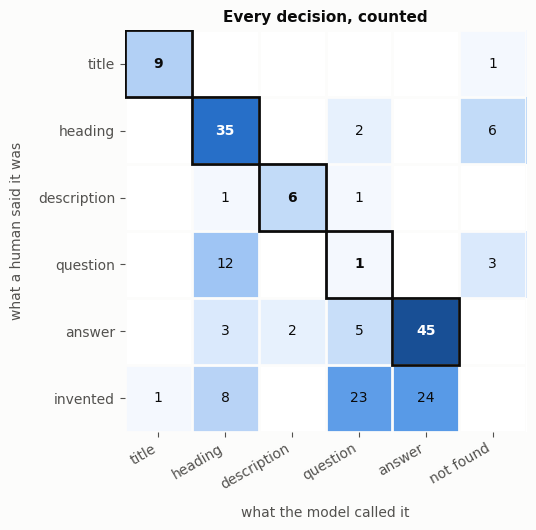

Biggest mistakes:

   24  invented a answer not present in the annotation
   23  invented a question not present in the annotation
   12  question called a heading
    8  invented a heading not present in the annotation
    6  heading the model produced nothing for
    5  answer called a question


In [4]:
short = ['title', 'heading', 'description', 'question', 'answer']

grid = np.zeros((len(LABELS) + 1, len(LABELS) + 1), dtype=int)
for i, true in enumerate(LABELS):
    for j, pred in enumerate(LABELS):
        grid[i, j] = conf.get(true, {}).get(pred, 0)
    grid[i, -1] = conf.get(true, {}).get('__missed__', 0)
for j, pred in enumerate(LABELS):
    grid[-1, j] = conf.get('__no_gold__', {}).get(pred, 0)

fig, ax = plt.subplots(figsize=(7.6, 5.4))
ax.imshow(grid, cmap=BLUES, vmin=0, vmax=grid.max())

for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        if grid[i, j]:
            # Label ink follows contrast against the cell, not the series colour.
            ax.text(j, i, str(grid[i, j]), ha='center', va='center', fontsize=10,
                    fontweight='bold' if i == j else 'normal',
                    color='#ffffff' if grid[i, j] > grid.max() * 0.55 else INK)

ax.set_xticks(range(len(short) + 1))
ax.set_xticklabels(short + ['not found'], rotation=30, ha='right')
ax.set_yticks(range(len(short) + 1))
ax.set_yticklabels(short + ['invented'])
ax.set_xlabel('what the model called it', labelpad=10)
ax.set_ylabel('what a human said it was', labelpad=10)
ax.set_title('Every decision, counted')

ax.set_xticks(np.arange(-.5, grid.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-.5, grid.shape[0], 1), minor=True)
ax.grid(which='minor', color=SURFACE, linewidth=2)
ax.tick_params(which='minor', length=0)

# Outline the diagonal so agreement is findable without reading colour.
# Drawn after the grid, or the grid paints over the edges.
for k in range(len(LABELS)):
    ax.add_patch(plt.Rectangle((k - .5, k - .5), 1, 1, fill=False,
                               edgecolor=INK, linewidth=2.0, zorder=5))
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

rows, cols = short + ['invented'], short + ['not found']
mistakes = sorted(((grid[i, j], rows[i], cols[j])
                   for i in range(grid.shape[0]) for j in range(grid.shape[1])
                   if i != j and grid[i, j]), reverse=True)
print('Biggest mistakes:')
print()
for count, true, pred in mistakes[:6]:
    if true == 'invented':
        print(f'  {count:>3}  invented a {pred} not present in the annotation')
    elif pred == 'not found':
        print(f'  {count:>3}  {true} the model produced nothing for')
    else:
        print(f'  {count:>3}  {true} called a {pred}')
